In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [7]:
# Load your data
df = pd.read_csv('imdb_dataset.csv')
X = df['review']
y = df['sentiment'].map({'positive': 1, 'negative': 0})

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorize text (Common for all models)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

Logistic Regression

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



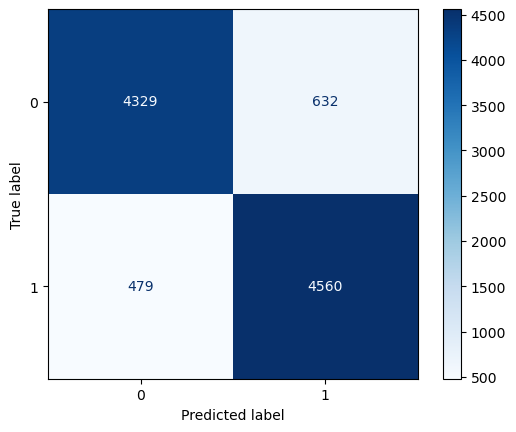

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1500,
    C=0.5,
    solver="liblinear"
)

lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression (Modified)")
print(classification_report(y_test, y_pred_lr))
ConfusionMatrixDisplay.from_estimator(lr_model, X_test_tfidf, y_test)
plt.show()


Random Forest

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      4961
           1       0.86      0.84      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



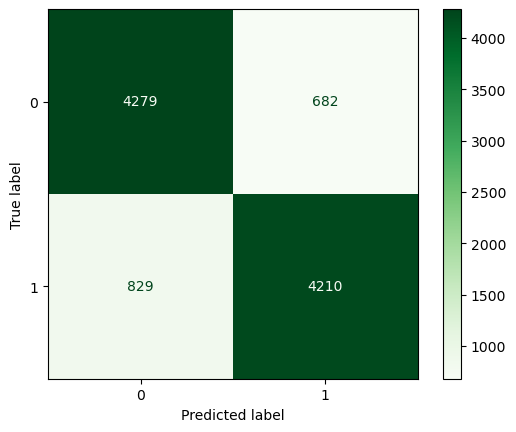

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)

print("Random Forest (Modified)")
print(classification_report(y_test, y_pred_rf))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test_tfidf, y_test)
plt.show()


Decision Tree

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.79      0.67      0.73      4961
           1       0.72      0.82      0.77      5039

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000



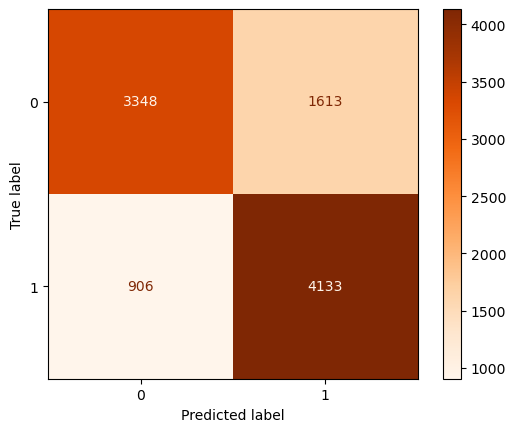

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=10,
    criterion="entropy",
    random_state=42
)

dt_model.fit(X_train_tfidf, y_train)
y_pred_dt = dt_model.predict(X_test_tfidf)

print("Decision Tree (Modified)")
print(classification_report(y_test, y_pred_dt))
ConfusionMatrixDisplay.from_estimator(dt_model, X_test_tfidf, y_test)
plt.show()


SVM

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=0.5,
    max_iter=3000
)

svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM (Modified)")
print(classification_report(y_test, y_pred_svm))
ConfusionMatrixDisplay.from_estimator(svm_model, X_test_tfidf, y_test)
plt.show()


XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_model.fit(X_train_tfidf, y_train)
y_pred_xgb = xgb_model.predict(X_test_tfidf)

print("XGBoost (Modified)")
print(classification_report(y_test, y_pred_xgb))
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test_tfidf, y_test)
plt.show()


KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance",
    metric="minkowski"
)

knn_model.fit(X_train_tfidf, y_train)
y_pred_knn = knn_model.predict(X_test_tfidf)

print("KNN (Modified)")
print(classification_report(y_test, y_pred_knn))
ConfusionMatrixDisplay.from_estimator(knn_model, X_test_tfidf, y_test)
plt.show()
